# Preprocess Data

Leave the dataset clean and structured for analysis/modeling.

## Index

- [Preprocess Data](#preprocess-data)
  - [Loading libraries](#loading-libraries)
  - [Data Loading](#data-loading)
  - [Type conversion (date, weather)](#type-conversion-date-weather)
  - [Extracting date components: year, month, weekday](#extracting-date-components-year-month-weekday)
  - [Handling nulls and extreme values](#handling-nulls-and-extreme-values)
  - [Save Changes](#save-changes)

## Loading libraries

In [ ]:
# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

# Preprocess
from scipy import stats

# Configuración matplotlib
plt.style.use('ggplot')

# Paths
import sys
import os
sys.path.append(os.path.abspath('../scripts'))
from paths import Paths

# Scripts
from preprocess_scripts import identify_outliers, treat_outliers, quick_outlier_analysis

## Data Loading

In [3]:
## Dowload DataSet:
# https://www.kaggle.com/code/markmedhat/weather-seattle/input

data = pd.read_csv(str(Paths.DATA_RAW)+"/seattle-weather.csv")
print(data.head(5))

         date  precipitation  temp_max  temp_min  wind  weather
0  2012-01-01            0.0      12.8       5.0   4.7  drizzle
1  2012-01-02           10.9      10.6       2.8   4.5     rain
2  2012-01-03            0.8      11.7       7.2   2.3     rain
3  2012-01-04           20.3      12.2       5.6   4.7     rain
4  2012-01-05            1.3       8.9       2.8   6.1     rain


## Type conversion (date, weather)

In [4]:
data["date"] = pd.to_datetime(data["date"])
print(data["date"].describe())

count                   1461
mean     2013-12-31 00:00:00
min      2012-01-01 00:00:00
25%      2012-12-31 00:00:00
50%      2013-12-31 00:00:00
75%      2014-12-31 00:00:00
max      2015-12-31 00:00:00
Name: date, dtype: object


## Extracting date components: year, month, weekday

In [5]:
data['year'] = data['date'].dt.year
data['month'] = data['date'].dt.month
data['day'] = data['date'].dt.day
print(data)

           date  precipitation  temp_max  temp_min  wind  weather  year  \
0    2012-01-01            0.0      12.8       5.0   4.7  drizzle  2012   
1    2012-01-02           10.9      10.6       2.8   4.5     rain  2012   
2    2012-01-03            0.8      11.7       7.2   2.3     rain  2012   
3    2012-01-04           20.3      12.2       5.6   4.7     rain  2012   
4    2012-01-05            1.3       8.9       2.8   6.1     rain  2012   
...         ...            ...       ...       ...   ...      ...   ...   
1456 2015-12-27            8.6       4.4       1.7   2.9     rain  2015   
1457 2015-12-28            1.5       5.0       1.7   1.3     rain  2015   
1458 2015-12-29            0.0       7.2       0.6   2.6      fog  2015   
1459 2015-12-30            0.0       5.6      -1.0   3.4      sun  2015   
1460 2015-12-31            0.0       5.6      -2.1   3.5      sun  2015   

      month  day  
0         1    1  
1         1    2  
2         1    3  
3         1    4  
4   

## Handling nulls and extreme values

Outlier treatment is applied using the CAP method (percentile winsorization) for exploratory purposes. This reduces the influence of extreme values ​​on descriptive statistics, without assuming that all extreme values ​​are errors. The objective is to illustrate the impact of these values ​​on the wind speed analysis and assess the need for their correction according to the context. In this particular case, the CAP method is used for illustrative and methodological purposes and does not necessarily imply that all extreme values ​​correspond to errors. The criterion for retaining or permanently excluding extreme values ​​will depend on the final objective of the analysis and the technical validation of the dataset.

=== ANÁLISIS DE OUTLIERS: wind ===
Total de datos: 1461
Valores nulos: 0
Estadísticas básicas:
  Media: 3.24
  Mediana: 3.00
  Desv. estándar: 1.44

Método IQR:
  Outliers encontrados: 34
  Porcentaje: 2.33%
  Límites: (-0.50, 6.70)



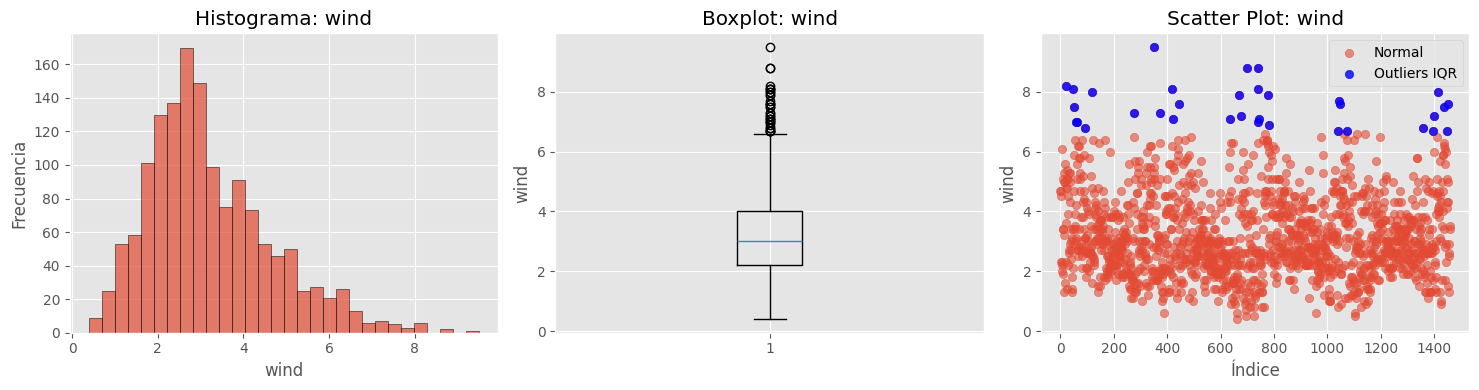

=== TRATAMIENTO DE OUTLIERS: wind ===
Outliers a tratar: 34
Valores limitados entre 1.30 y 6.00

Estadísticas después del tratamiento:
  Media: 3.21
  Mediana: 3.00
  Desv. estándar: 1.34
  Filas restantes: 1461


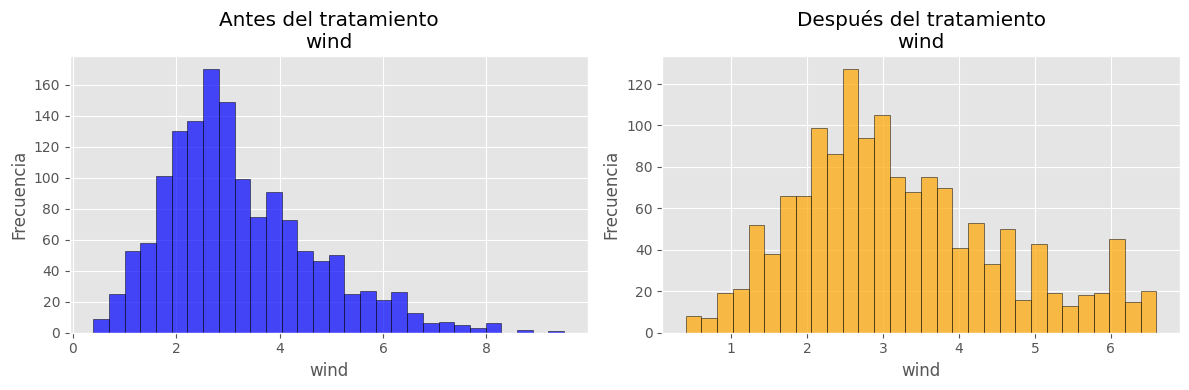

In [6]:
df_limpio = quick_outlier_analysis(data, 'wind', method='iqr', treatment='cap')

## Save Changes

In [7]:
df_limpio.to_csv(str(Paths.DATA_PROCESSED)+'/preprocess_data.csv', index=False)